## EDA – Monthly Inflow and Outflow (FLE0100b)
---
- This notebook analyses monthly vessel inflows and outflows in the UK Ship
Register to understand short‑term dynamics behind the long‑term decline
observed in the annual statistics.


In [1]:
import pandas as pd
import matplotlib.pyplot as plot

In [49]:
df_b = pd.read_csv("../data/raw/fle100b(FLE0100b).csv", 
                   skiprows= 5,
                   header= None)

df_b.head()

,0,1,2,3,4,5,6,7
0,Year,Month,Metric [note 6],Flagged in,Flagged out,Total [note 5],NaN,NaN
1,2015,January,MCA all merchant (trading) vessels,4,6,"1,323",NaN,NaN
2,2015,Februrary,MCA all merchant (trading) vessels,6,4,"1,323",NaN,NaN
3,2015,March,MCA all merchant (trading) vessels,6,5,"1,325",NaN,NaN
4,2015,April,MCA all merchant (trading) vessels,9,13,"1,323",NaN,NaN


In [50]:
df_b.columns = df_b.iloc[0]
df_b = df_b.iloc[1:].reset_index(drop=True)

f_b = df_b.loc[:, ~df_b.columns.astype(str).str.contains("^Unnamed")]


df_b.columns = (df_b.columns.astype(str)
                .str.lower()
                .str.replace("[^a-z0-9_]", " ", regex=True)
)

df_b.head()

,year,month,metric note 6,flagged in,flagged out,total note 5,nan,nan
0,2015,January,MCA all merchant (trading) vessels,4,6,"1,323",NaN,NaN
1,2015,Februrary,MCA all merchant (trading) vessels,6,4,"1,323",NaN,NaN
2,2015,March,MCA all merchant (trading) vessels,6,5,"1,325",NaN,NaN
3,2015,April,MCA all merchant (trading) vessels,9,13,"1,323",NaN,NaN
4,2015,May,MCA all merchant (trading) vessels,10,3,"1,323",NaN,NaN


In [54]:
df_b.columns

Index(['year ', 'month', 'metric  note 6 ', 'flagged in', 'flagged out',
       'total  note 5 ', 'nan', 'nan'],
      dtype='object', name=0)

In [56]:
df_monthly = df_b[df_b["metric  note 6 "].str.contains("vessel", case=False, na=False)].copy()

df_monthly.head()


,year,month,metric note 6,flagged in,flagged out,total note 5,nan,nan
0,2015,January,MCA all merchant (trading) vessels,4,6,"1,323",NaN,NaN
1,2015,Februrary,MCA all merchant (trading) vessels,6,4,"1,323",NaN,NaN
2,2015,March,MCA all merchant (trading) vessels,6,5,"1,325",NaN,NaN
3,2015,April,MCA all merchant (trading) vessels,9,13,"1,323",NaN,NaN
4,2015,May,MCA all merchant (trading) vessels,10,3,"1,323",NaN,NaN


In [57]:
df_monthly["flagged in"] = pd.to_numeric(
    df_monthly["flagged in"], errors="coerce"
)

df_monthly["flagged out"] = pd.to_numeric(
    df_monthly["flagged out"], errors="coerce"
)

df_monthly["net_flow"] = (
    df_monthly["flagged in"] - df_monthly["flagged out"]
)

df_monthly.head()

,year,month,metric note 6,flagged in,flagged out,total note 5,nan,nan,net_flow
0,2015,January,MCA all merchant (trading) vessels,4,6,"1,323",NaN,NaN,-2
1,2015,Februrary,MCA all merchant (trading) vessels,6,4,"1,323",NaN,NaN,2
2,2015,March,MCA all merchant (trading) vessels,6,5,"1,325",NaN,NaN,1
3,2015,April,MCA all merchant (trading) vessels,9,13,"1,323",NaN,NaN,-4
4,2015,May,MCA all merchant (trading) vessels,10,3,"1,323",NaN,NaN,7


In [95]:
df_monthly["date"] = pd.to_datetime(
    df_monthly["year "].astype(str) + "-" + df_monthly["month"],
    format="%Y-%B",
    errors="coerce"
)

df_monthly = df_monthly.sort_values("date")
df_monthly.head()

,year,month,metric note 6,flagged in,flagged out,total note 5,nan,nan,net_flow,date,net_flow_6m_avg
0,2015,January,MCA all merchant (trading) vessels,4,6,"1,323",NaN,NaN,-2,2015-01-01,NaN
3,2015,April,MCA all merchant (trading) vessels,9,13,"1,323",NaN,NaN,-4,2015-04-01,-1.666667
5,2015,June,MCA all merchant (trading) vessels,7,7,"1,321",NaN,NaN,0,2015-06-01,0.400000
6,2015,July,MCA all merchant (trading) vessels,9,3,"1,327",NaN,NaN,6,2015-07-01,1.333333
7,2015,August,MCA all merchant (trading) vessels,5,3,"1,328",NaN,NaN,2,2015-08-01,2.000000


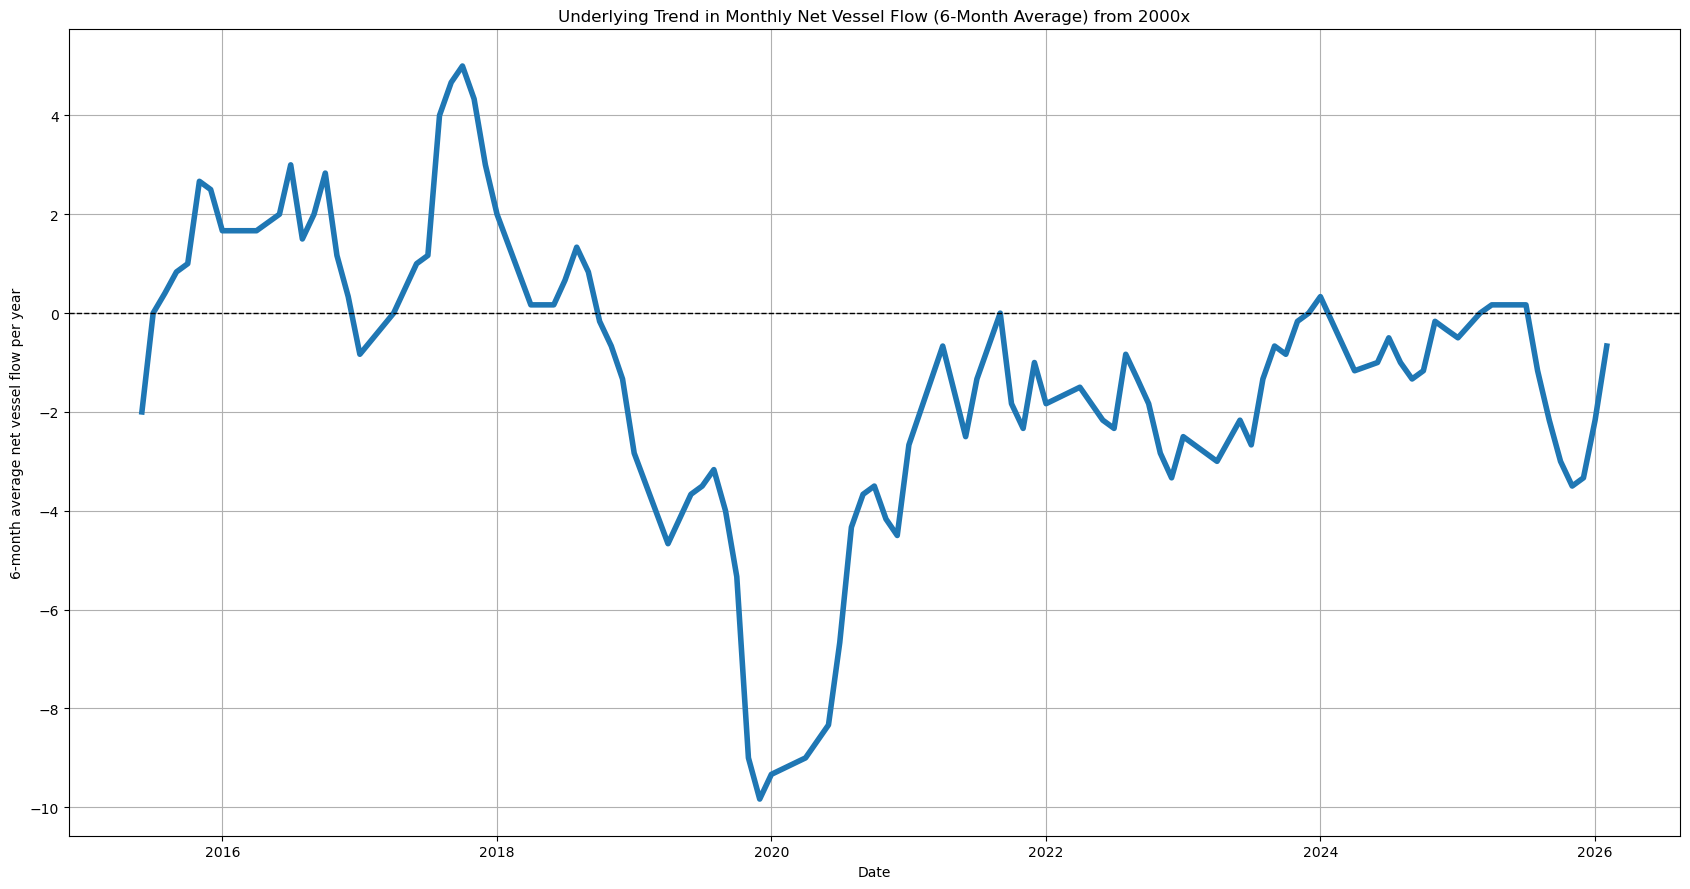

In [96]:
df_monthly["net_flow_6m_avg"] = (
    df_monthly["net_flow"]
    .rolling(window=6, min_periods=3)
    .mean()
)

plt.figure(figsize=(17, 9))

plt.plot(
    df_monthly["date"],
    df_monthly["net_flow_6m_avg"],
    linewidth=4
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Date")
plt.ylabel("6‑month average net vessel flow per year")
plt.title("Underlying Trend in Monthly Net Vessel Flow (6‑Month Average) from 2000x")
plt.grid(True)
plt.tight_layout()
plt.show()

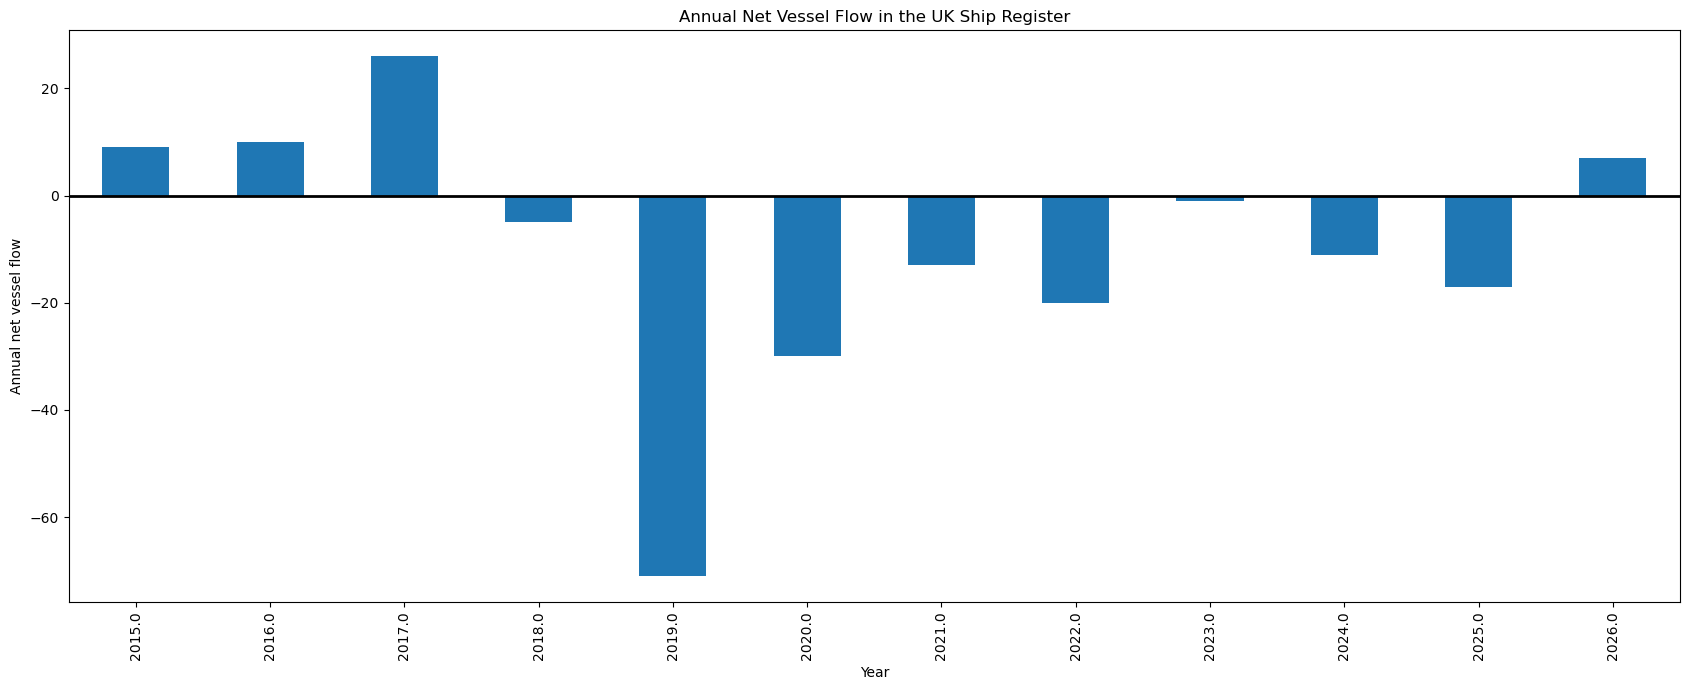

In [97]:
df_annual_net = (
    df_monthly
    .groupby(df_monthly["date"].dt.year)["net_flow"]
    .sum()
)

plt.figure(figsize=(17, 7))

df_annual_net.plot(kind="bar")

plt.axhline(0, color="black", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Annual net vessel flow")
plt.title("Annual Net Vessel Flow in the UK Ship Register")
plt.tight_layout()
plt.show()